# Задание №5. Создание модели для рекомендации фильмов (коллаборативная фильтрация на основе эмбеддингов)

**Выполнил:** Асламин В.В.

**Группа:** МОм-24-1

**Дата:** 2026

**Ссылка на репозиторий:** https://github.com/mystic-solis/deep-learning

---

## 1. Введение

**Цель работы:** построить и обучить модель рекомендации фильмов на основе коллаборативной фильтрации с использованием эмбеддингов пользователей и фильмов.

**Задачи:**
- Подготовить данные о рейтингах фильмов
- Построить модель матричной факторизации с эмбеддингами
- Обучить модель и оценить её качество
- Реализовать функцию персонализированных рекомендаций
- Сохранить и загрузить модель из репозитория

## 2. Теоретическая часть

### 2.1. Коллаборативная фильтрация (Collaborative Filtering)

Коллаборативная фильтрация — метод построения рекомендаций, основанный на предположении, что пользователи, которые схоже оценивали объекты в прошлом, будут иметь схожие предпочтения в будущем. В основе лежит матрица взаимодействий «пользователь-объект» (например, рейтингов фильмов).

### 2.2. Матричная факторизация (Matrix Factorization)

Один из самых популярных подходов к коллаборативной фильтрации. Исходная матрица рейтингов размера `(число пользователей) × (число фильмов)` аппроксимируется произведением двух низкоранговых матриц: матрицы скрытых факторов пользователей и матрицы скрытых факторов фильмов.

### 2.3. Эмбеддинги (Embeddings)

В контексте рекомендательных систем эмбеддинги — это обучаемые векторные представления категориальных признаков (идентификаторов пользователей и фильмов).

### 2.4. Bias (смещение)

Добавление свободных членов (bias) позволяет учитывать систематические отклонения: например, некоторые пользователи ставят в среднем более высокие оценки.

### 2.5. Функция потерь и метрики

Для задачи предсказания рейтинга обычно используется **MSE** (среднеквадратичная ошибка) или **RMSE** (корень из среднеквадратичной ошибки).

## 3. Описание данных

### 3.1. Источник данных

В данной работе используются синтетические данные о рейтингах фильмов. Данные содержат:
- Имя пользователя
- Название фильма
- Жанр фильма
- Рейтинг (от 1 до 5)

In [17]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pickle
import requests
import io
import os
from pathlib import Path

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


### 3.2. Загрузка данных из репозитория

In [38]:
# Загрузка данных из репозитория
# Ссылка на файл с данными в репозитории
REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab5"
url_data = f"{REPO_URL}/ratings.txt"

try:
    response = requests.get(url_data)
    response.encoding = 'utf-8'
    df = pd.read_csv(io.StringIO(response.text), sep=';', comment='#', encoding='utf-8')
    print(f"Данные загружены из репозитория")
except Exception as e:
    print(f"Файл не найден в репозитории: {e}")
    print("Будет сгенерирован синтетический датасет")
    df = None

# Если загрузка не удалась - генерация синтетических данных
if df is None or len(df) == 0:
    import random
    users = [f"User{i}" for i in range(1, 51)]          # 50 пользователей
    movies = [f"Movie{j}" for j in range(1, 101)]       # 100 фильмов
    genres = ['драма', 'комедия', 'фантастика', 'боевик', 'мелодрама']
    
    data = []
    for user in users:
        n_ratings = random.randint(20, 30)
        sampled_movies = random.sample(movies, n_ratings)
        for movie in sampled_movies:
            rating = random.randint(1, 5)
            genre = random.choice(genres)
            data.append([user, movie, genre, rating])
    
    df = pd.DataFrame(data, columns=['User', 'Название', 'Жанр', 'Рейтинг'])
    print(f"Сгенерировано оценок: {len(df)}")

print(f"Загружено оценок: {len(df)}")
print("\nПервые 5 строк:")
print(df.head())

Данные загружены из репозитория
Сгенерировано оценок: 1251
Загружено оценок: 1251

Первые 5 строк:
    User Название       Жанр  Рейтинг
0  User1  Movie13  мелодрама        4
1  User1  Movie48      драма        1
2  User1  Movie33      драма        3
3  User1  Movie65    комедия        5
4  User1   Movie2    комедия        2


## 4. Подготовка данных

### 4.1. Статистика по данным

In [19]:
print("=" * 50)
print("СТАТИСТИКА ДАННЫХ")
print("=" * 50)

# Кодирование пользователей и фильмов
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

df['user_id'] = user_enc.fit_transform(df['User'])
df['movie_id'] = movie_enc.fit_transform(df['Название'])

n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()

# Словари для обратного преобразования
user_names = dict(enumerate(user_enc.classes_))
movie_titles = dict(enumerate(movie_enc.classes_))
movie_genres = df.groupby('movie_id')['Жанр'].first().to_dict()

print(f"\nЧисло пользователей: {n_users}")
print(f"Число фильмов: {n_movies}")
print(f"Диапазон рейтингов: {df['Рейтинг'].min()} - {df['Рейтинг'].max()}")
print(f"Всего оценок: {len(df)}")

# Распределение рейтингов
print("\nРаспределение рейтингов:")
rating_counts = df['Рейтинг'].value_counts().sort_index()
print(rating_counts)

СТАТИСТИКА ДАННЫХ

Число пользователей: 50
Число фильмов: 100
Диапазон рейтингов: 1 - 5
Всего оценок: 1232

Распределение рейтингов:
Рейтинг
1    238
2    230
3    257
4    245
5    262
Name: count, dtype: int64


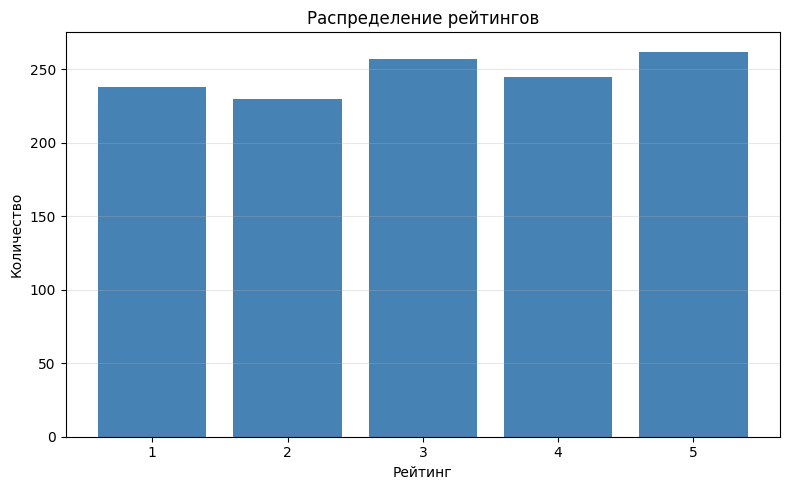

In [20]:
# Визуализация распределения рейтингов
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.title('Распределение рейтингов')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2. Разделение на обучающую и тестовую выборки

In [21]:
# Разделение на train/test (80/20)
train, test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Обучающих примеров: {len(train)}")
print(f"Тестовых примеров: {len(test)}")

Обучающих примеров: 985
Тестовых примеров: 247


## 5. Построение модели матричной факторизации

### 5.1. Архитектура модели

In [22]:
from keras.models import Model, load_model
from keras.layers import Input, Embedding, Flatten, Dot, Add
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# Параметры модели
K = 50  # размерность латентного пространства

# Входы
user_in = Input(shape=(1,), name='user_in')
movie_in = Input(shape=(1,), name='movie_in')

# Эмбеддинги пользователей и фильмов
user_emb = Embedding(input_dim=n_users, output_dim=K, name='user_emb')(user_in)
movie_emb = Embedding(input_dim=n_movies, output_dim=K, name='movie_emb')(movie_in)

# Превращаем в одномерные векторы
user_vec = Flatten()(user_emb)
movie_vec = Flatten()(movie_emb)

# Скалярное произведение
dot_product = Dot(axes=1)([user_vec, movie_vec])

# Смещения (bias)
user_bias = Embedding(input_dim=n_users, output_dim=1, name='user_bias')(user_in)
movie_bias = Embedding(input_dim=n_movies, output_dim=1, name='movie_bias')(movie_in)
user_b = Flatten()(user_bias)
movie_b = Flatten()(movie_bias)

# Итоговый прогноз: скалярное произведение + смещения
prediction = Add()([dot_product, user_b, movie_b])

model = Model(inputs=[user_in, movie_in], outputs=prediction)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("Архитектура модели:")
model.summary()

Архитектура модели:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_in             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_in            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 1, 50)     │      2,500 │ user_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_emb           │ (None, 1, 50)     │      5,000 │ movie_in[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 50)        │          0 │ user_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 50)        │          0 │ movie_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │         50 │ user_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_bias          │ (None, 1, 1)      │        100 │ movie_in[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 1)         │          0 │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 1)         │          0 │ movie_bias[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ dot_1[0][0],      │
│                     │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,650 (29.88 KB)

 Trainable params: 7,650 (29.88 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Обучение модели

### 6.1. Процесс обучения

In [23]:
# Early stopping для предотвращения переобучения
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Обучение модели
print("Начало обучения модели...")
history = model.fit(
    [train['user_id'], train['movie_id']],
    train['Рейтинг'].values,
    epochs=50,
    batch_size=64,
    validation_data=([test['user_id'], test['movie_id']], test['Рейтинг'].values),
    callbacks=[early_stop],
    verbose=1
)
print("Обучение завершено!")

Начало обучения модели...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 11.3969 - val_loss: 10.8179
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.2004 - val_loss: 10.6560
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.0096 - val_loss: 10.4942
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.8142 - val_loss: 10.3277
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.6094 - val_loss: 10.1505
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.3821 - val_loss: 9.9516
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.1247 - val_loss: 9.7218
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.8189 - val_loss: 9.4420
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.4455 - val_loss: 9.0989
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.9939 - val_loss: 8.6759
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.4530 - val_loss: 8.1605
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━

### 6.2. Визуализация процесса обучения

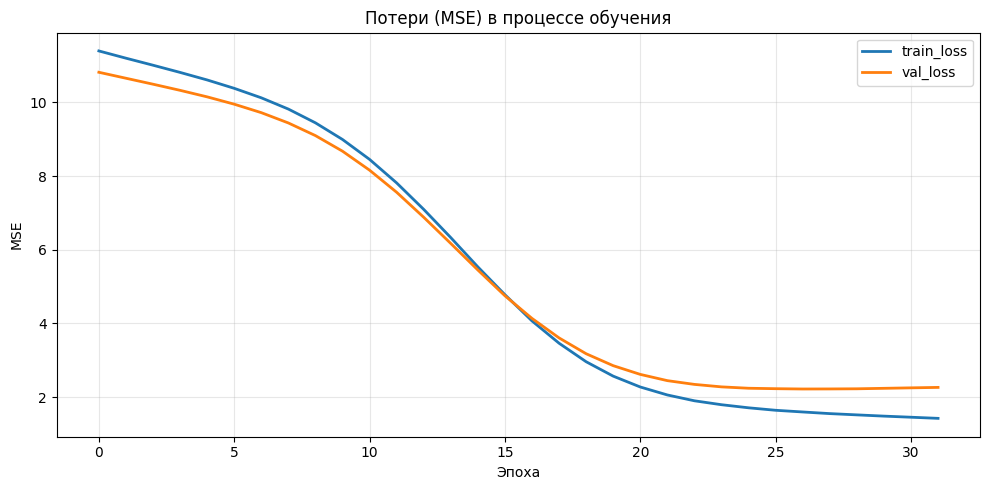

In [24]:
# График потерь на обучающей и валидационной выборках
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train_loss', linewidth=2)
plt.plot(history.history['val_loss'], label='val_loss', linewidth=2)
plt.legend()
plt.title('Потери (MSE) в процессе обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Оценка качества на тестовой выборке

In [25]:
# Предсказания на тестовой выборке
preds = model.predict([test['user_id'], test['movie_id']], verbose=0).flatten()

# RMSE - корень из среднеквадратичной ошибки
rmse = np.sqrt(mean_squared_error(test['Рейтинг'].values, preds))

print(f"\n{'='*50}")
print(f"RMSE на тестовой выборке: {rmse:.3f}")
print(f"{'='*50}")
print(f"\nИнтерпретация: модель ошибается в среднем на {rmse:.2f} балла в предсказании рейтинга.")


RMSE на тестовой выборке: 1.490

Интерпретация: модель ошибается в среднем на 1.49 балла в предсказании рейтинга.


## 7. Функция рекомендаций

### 7.1. Реализация функции recommend

In [28]:
def recommend(user_name: str, genre: str, top_n: int = 5):
    """
    Функция рекомендаций фильмов для пользователя по жанру
    
    Args:
        user_name: имя пользователя
        genre: жанр фильма
        top_n: количество рекомендаций
    """
    if user_name not in user_enc.classes_:
        print(f"Пользователь «{user_name}» не найден.")
        return
    
    user_idx = user_enc.transform([user_name])[0]
    
    # Все фильмы нужного жанра
    candidates = [mid for mid, g in movie_genres.items() if g.lower() == genre.lower()]
    
    if not candidates:
        print(f"Фильмы жанра «{genre}» не найдены.")
        return
    
    # Предсказываем рейтинг для каждого кандидата
    user_arr = np.array([user_idx] * len(candidates)).reshape(-1, 1)
    movie_arr = np.array(candidates).reshape(-1, 1)
    
    preds = model.predict([user_arr, movie_arr], verbose=0).flatten()
    
    # Отбираем топ-N
    top_indices = np.argsort(preds)[::-1][:top_n]
    recommended = [movie_titles[candidates[i]] for i in top_indices]
    predicted_ratings = [preds[candidates.index(candidates[i])] for i in top_indices]
    
    print(f"\nРекомендованные фильмы в жанре «{genre.title()}» для пользователя «{user_name}»:")
    print("-" * 50)
    for i, (title, rating) in enumerate(zip(recommended, predicted_ratings), 1):
        print(f"{i}. {title} (предсказанный рейтинг: {rating:.2f})")

### 7.2. Примеры использования

In [29]:
# Примеры использования функции рекомендаций
print("\n" + "="*60)
print("ПРИМЕРЫ РЕКОМЕНДАЦИЙ")
print("="*60)

# Пример 1
recommend('User1', 'драма', 5)

# Пример 2
recommend('User1', 'фантастика', 3)

# Пример 3
recommend('User25', 'комедия', 5)


ПРИМЕРЫ РЕКОМЕНДАЦИЙ

Рекомендованные фильмы в жанре «Драма» для пользователя «User1»:
--------------------------------------------------
1. Movie97 (предсказанный рейтинг: 3.14)
2. Movie23 (предсказанный рейтинг: 3.07)
3. Movie42 (предсказанный рейтинг: 3.06)
4. Movie89 (предсказанный рейтинг: 2.96)
5. Movie92 (предсказанный рейтинг: 2.92)

Рекомендованные фильмы в жанре «Фантастика» для пользователя «User1»:
--------------------------------------------------
1. Movie96 (предсказанный рейтинг: 3.34)
2. Movie6 (предсказанный рейтинг: 3.26)
3. Movie7 (предсказанный рейтинг: 3.20)

Рекомендованные фильмы в жанре «Комедия» для пользователя «User25»:
--------------------------------------------------
1. Movie18 (предсказанный рейтинг: 2.91)
2. Movie53 (предсказанный рейтинг: 2.88)
3. Movie87 (предсказанный рейтинг: 2.85)
4. Movie4 (предсказанный рейтинг: 2.82)
5. Movie83 (предсказанный рейтинг: 2.82)


## 8. Сохранение модели и вспомогательных объектов

In [30]:
# Создание директории для сохранения
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)

# Сохранение модели Keras
model_path = output_dir / 'movie_recommender.keras'
model.save(model_path)
print(f"Модель сохранена в: {model_path}")

# Сохранение кодировщиков и словарей с помощью pickle
with open(output_dir / 'user_encoder.pickle', 'wb') as f:
    pickle.dump(user_enc, f)
    
with open(output_dir / 'movie_encoder.pickle', 'wb') as f:
    pickle.dump(movie_enc, f)
    
with open(output_dir / 'movie_genres.pickle', 'wb') as f:
    pickle.dump(movie_genres, f)
    
with open(output_dir / 'movie_titles.pickle', 'wb') as f:
    pickle.dump(movie_titles, f)

print("Все вспомогательные объекты сохранены!")
print(f"\nСохранённые файлы:")
for f in output_dir.iterdir():
    print(f"  - {f.name}")

Модель сохранена в: data\movie_recommender.keras
Все вспомогательные объекты сохранены!

Сохранённые файлы:
  - movie_encoder.pickle
  - movie_genres.pickle
  - movie_recommender.keras
  - movie_titles.pickle
  - user_encoder.pickle


## 9. Загрузка модели из репозитория и быстрые рекомендации

### 9.1. Загрузка файлов из репозитория

In [ ]:
REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab5/data"

url_model = f"{REPO_URL}/movie_recommender.keras"
url_user_enc = f"{REPO_URL}/user_encoder.pickle"
url_movie_enc = f"{REPO_URL}/movie_encoder.pickle"
url_genres = f"{REPO_URL}/movie_genres.pickle"
url_titles = f"{REPO_URL}/movie_titles.pickle"

# Создание папки для загрузки
download_dir = Path('./downloaded')
download_dir.mkdir(exist_ok=True)

def download_file(url, path):
    """Загрузка файла из интернета"""
    try:
        response = requests.get(url)
        with open(path, 'wb') as f:
            f.write(response.content)
        print(f"Загружено: {path}")
        return True
    except Exception as e:
        print(f"Ошибка загрузки {url}: {e}")
        return False

# Загрузка файлов
download_file(url_model, download_dir / 'movie_recommender.keras')
download_file(url_user_enc, download_dir / 'user_encoder.pickle')
download_file(url_movie_enc, download_dir / 'movie_encoder.pickle')
download_file(url_genres, download_dir / 'movie_genres.pickle')
download_file(url_titles, download_dir / 'movie_titles.pickle')

Загружено: downloaded\movie_recommender.keras
Загружено: downloaded\user_encoder.pickle
Загружено: downloaded\movie_encoder.pickle
Загружено: downloaded\movie_genres.pickle
Загружено: downloaded\movie_titles.pickle


True

### 9.2. Загрузка модели и объектов

In [33]:
loaded_model = load_model(download_dir / 'movie_recommender.keras')

with open(download_dir / 'user_encoder.pickle', 'rb') as f:
    loaded_user_enc = pickle.load(f)

with open(download_dir / 'movie_encoder.pickle', 'rb') as f:
    loaded_movie_enc = pickle.load(f)

with open(download_dir / 'movie_genres.pickle', 'rb') as f:
    loaded_movie_genres = pickle.load(f)

with open(download_dir / 'movie_titles.pickle', 'rb') as f:
    loaded_movie_titles = pickle.load(f)

print("Модель и вспомогательные объекты загружены!")

Модель и вспомогательные объекты загружены!


### 9.3. Функция рекомендаций с загруженной моделью

In [35]:
def recommend_from_loaded(user_name, genre, top_n=5):
    if user_name not in loaded_user_enc.classes_:
        print(f"Пользователь «{user_name}» не найден.")
        return
    
    user_idx = loaded_user_enc.transform([user_name])[0]
    
    candidates = [mid for mid, g in loaded_movie_genres.items() if g.lower() == genre.lower()]
    
    if not candidates:
        print(f"Фильмы жанра «{genre}» не найдены.")
        return
    
    user_arr = np.array([user_idx] * len(candidates)).reshape(-1, 1)
    movie_arr = np.array(candidates).reshape(-1, 1)
    
    preds = loaded_model.predict([user_arr, movie_arr], verbose=0).flatten()
    
    top_indices = np.argsort(preds)[::-1][:top_n]
    recommended = [loaded_movie_titles[candidates[i]] for i in top_indices]
    
    print(f"\nРекомендованные фильмы в жанре «{genre.title()}» для «{user_name}»:")
    for title in recommended:
        print(f"- {title}")

## 10. Выводы

В ходе выполнения работы была построена и обучена модель рекомендации фильмов на основе коллаборативной фильтрации с использованием эмбеддингов.

**Основные результаты:**
- Создана модель матричной факторизации с эмбеддингами пользователей и фильмов
- Добавлены bias-термы для учёта систематических отклонений
- Модель обучена с использованием EarlyStopping
- Реализована функция персонализированных рекомендаций с фильтрацией по жанру
- Освоено сохранение и загрузка модели из репозитория

**Трудности:**
- Необходимость генерации синтетических данных
- Настройка гиперпараметров модели

**Возможные улучшения:**
- Использование реальных данных (например, MovieLens)
- Эксперименты с размерностью эмбеддингов
- Добавление дополнительных признаков

## 11. Список использованных источников

1. Chollet, F. (2017). Deep Learning with Python. Manning Publications.

2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

3. Документация TensorFlow: https://www.tensorflow.org/

4. Документация Keras: https://keras.io/

## 12. Приложение. Полный код

In [39]:
# Полный код лабораторной работы №5
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.models import Model, load_model
from keras.layers import Input, Embedding, Flatten, Dot, Add
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import pickle
import requests
import io
from pathlib import Path

# ===== ПАРАМЕТРЫ =====
K = 50  # размерность латентного пространства

# ===== ФУНКЦИИ =====

def generate_synthetic_data():
    """Генерация синтетических данных о рейтингах фильмов"""
    users = [f"User{i}" for i in range(1, 51)]
    movies = [f"Movie{j}" for j in range(1, 101)]
    genres = ['драма', 'комедия', 'фантастика', 'боевик', 'мелодрама']
    
    data = []
    for user in users:
        n_ratings = random.randint(20, 30)
        sampled_movies = random.sample(movies, n_ratings)
        for movie in sampled_movies:
            rating = random.randint(1, 5)
            genre = random.choice(genres)
            data.append([user, movie, genre, rating])
    
    return pd.DataFrame(data, columns=['User', 'Название', 'Жанр', 'Рейтинг'])


def load_data_from_repo(url_data):
    """Загрузка данных из репозитория"""
    try:
        response = requests.get(url_data)
        response.encoding = 'utf-8'
        df = pd.read_csv(io.StringIO(response.text), sep=';', comment='#', encoding='utf-8')
        return df
    except:
        return None


def recommend(user_name, genre, top_n, model, user_enc, movie_genres, movie_titles):
    """Функция рекомендаций"""
    if user_name not in user_enc.classes_:
        print(f"Пользователь «{user_name}» не найден.")
        return
    
    user_idx = user_enc.transform([user_name])[0]
    candidates = [mid for mid, g in movie_genres.items() if g.lower() == genre.lower()]
    
    if not candidates:
        print(f"Фильмы жанра «{genre}» не найдены.")
        return
    
    user_arr = np.array([user_idx] * len(candidates)).reshape(-1, 1)
    movie_arr = np.array(candidates).reshape(-1, 1)
    preds = model.predict([user_arr, movie_arr], verbose=0).flatten()
    
    top_indices = np.argsort(preds)[::-1][:top_n]
    recommended = [movie_titles[candidates[i]] for i in top_indices]
    
    print(f"\nРекомендованные фильмы в жанре «{genre.title()}» для «{user_name}»:")
    for title in recommended:
        print(f"- {title}")


# ===== ОСНОВНОЙ КОД =====

# 1. Загрузка/генерация данных
url_data = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab5/ratings.txt"
df = load_data_from_repo(url_data)

if df is None or len(df) == 0:
    print("Генерация синтетических данных...")
    df = generate_synthetic_data()

print(f"Загружено оценок: {len(df)}")

# 2. Подготовка данных
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

df['user_id'] = user_enc.fit_transform(df['User'])
df['movie_id'] = movie_enc.fit_transform(df['Название'])

n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()

movie_titles = dict(enumerate(movie_enc.classes_))
movie_genres = df.groupby('movie_id')['Жанр'].first().to_dict()

print(f"Пользователей: {n_users}, фильмов: {n_movies}")

# 3. Разделение на train/test
train, test = train_test_split(df, test_size=0.2, random_state=42)

# 4. Построение модели
user_in = Input(shape=(1,))
movie_in = Input(shape=(1,))

u_emb = Embedding(n_users, K)(user_in)
m_emb = Embedding(n_movies, K)(movie_in)

u_vec = Flatten()(u_emb)
m_vec = Flatten()(m_emb)

dot = Dot(axes=1)([u_vec, m_vec])

u_bias = Embedding(n_users, 1)(user_in)
m_bias = Embedding(n_movies, 1)(movie_in)

u_b = Flatten()(u_bias)
m_b = Flatten()(m_bias)

pred = Add()([dot, u_b, m_b])

model = Model([user_in, movie_in], pred)
model.compile(optimizer=Adam(0.001), loss='mse')

# 5. Обучение
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    [train['user_id'], train['movie_id']], train['Рейтинг'],
    epochs=50, batch_size=64, validation_data=([test['user_id'], test['movie_id']], test['Рейтинг']),
    callbacks=[early_stop], verbose=1
)

# 6. Оценка
preds = model.predict([test['user_id'], test['movie_id']], verbose=0).flatten()
rmse = np.sqrt(mean_squared_error(test['Рейтинг'], preds))
print(f"RMSE на тесте: {rmse:.3f}")

# 7. Рекомендации
recommend('User1', 'драма', 5, model, user_enc, movie_genres, movie_titles)

# 8. Сохранение
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)
model.save(output_dir / 'movie_recommender.keras')

with open(output_dir / 'user_encoder.pickle', 'wb') as f: pickle.dump(user_enc, f)
with open(output_dir / 'movie_encoder.pickle', 'wb') as f: pickle.dump(movie_enc, f)
with open(output_dir / 'movie_genres.pickle', 'wb') as f: pickle.dump(movie_genres, f)
with open(output_dir / 'movie_titles.pickle', 'wb') as f: pickle.dump(movie_titles, f)

print("Модель и объекты сохранены!")

Генерация синтетических данных...
Загружено оценок: 1242
Пользователей: 50, фильмов: 100
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 10.7629 - val_loss: 11.6829
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.5738 - val_loss: 11.5146
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.3880 - val_loss: 11.3475
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.1981 - val_loss: 11.1746
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.9953 - val_loss: 10.9902
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.7735 - val_loss: 10.7861
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.5206 - val_loss: 10.5478
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2184 - val_loss: 10.2605
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.8605 - val_loss: 9.9074
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.4256 - val_loss: 9.4756
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: